In [1]:
%matplotlib widget
import json
from itertools import product
from functools import partial, reduce
from copy import deepcopy
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy as sp
import seaborn as sns
import tempfile
import multiprocessing as mp

import hopsy
import plotly.express as px
from diskcache import Cache
from freeflux import Model
from pathlib import Path
from tqdm import tqdm
from scipy.spatial.distance import pdist, cdist, cosine

from sklearn.model_selection import KFold, cross_val_score, train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

from mfa import (
    reac2array,
    create_add_constraints,
    get_model,
    make_bounds, 
    sample_fluxes, 
    get_mdv_results, 
    get_mdv_results_from_simulations,
    get_single_sim_result,
    get_reconex_fluxes,
    get_flux_ratio,
    get_flux_ratio_onlypos,
    get_flux_ratio,
    get_all_flux_ratios,
    subset_fluxes_by_binned_flux_ratio,
    subset_mdvs_by_binned_flux_ratio,
    train_rf
)
from flux_mdv_utils import (
    xy_line, 
    melt_flux_df, 
    melt_mdv_df,
    get_sumoflux_fluxes,
    get_flux_ratio,
    get_highest_flux_diff,
    get_highest_mdv_diff,
    convert_sumoflux_notation,
    plot_fluxes,
    plot_mdvs_boxplots,
    plot_rf_results
)

sns.set_theme()

cache = Cache("../.cache")

output_dir = Path("../Output") / Path(__session__).stem
output_dir.mkdir(parents=True, exist_ok=True)

parallel = 100


def read_config(path_to_file):
    with open(path_to_file) as fh:
        return json.load(fh)

def get_feat_importance(rf_results, feature_names):
    return pd.concat([
        (
            pd.DataFrame({
                "feature": feature_names, 
                "importance": ratio_res[0].feature_importances_
            })
            .assign(ratio_name=ratio_name)
            .sort_values("importance", ascending=False)
        ) for ratio_name, ratio_res in rf_results.items()
    ])

def predict_interval(model, X, lower=5, upper=95):
    # Collect predictions from all individual trees
    tree_preds = np.array([tree.predict(X) for tree in model.estimators_])
    # tree_preds shape: (n_estimators, n_samples)
    
    lower_bound = np.percentile(tree_preds, lower, axis=0)
    upper_bound = np.percentile(tree_preds, upper, axis=0)
    point_pred  = np.mean(tree_preds, axis=0)
    
    return point_pred, lower_bound, upper_bound

def get_rf_pred_results(rf_dict, df_exp, condition, q_lower=10, q_upper=90, replace_w_nans=True):
    pred_df = (
        pd.DataFrame([
            [
                condition, 
                ratio_name, 
                *predict_interval(ratio_res[0], df_exp.mdv.to_frame().transpose().values, q_lower, q_upper), 
                *ratio_res[1].values()
            ] 
            for ratio_name, ratio_res in rf_dict.items()
        ], columns=(
            "condition", 
            "flux_ratio", 
            "pred", 
            "pred_q10", 
            "pred_q90",
            "mae", 
            "cv_mae_mean", 
            "cv_mae_sd"
        ))
        .explode(["pred", "pred_q10", "pred_q90"])
        .pipe(lambda x: x.join(x.flux_ratio.str.extract(r"(?P<nucleoside>.*)_(?P<flux_ratio_name>.*)")))
    )
    
    if replace_w_nans and df_exp.mdv.isna().any():
        pred_df = pred_df.assign(pred=np.nan, pred_q10=np.nan, pred_q90=np.nan)
    return pred_df

def lineplots(data, x="pred", y="condition", **kwargs):
    sns.stripplot(
        data,
        x=x,
        y=y,
        hue=y,
    )
    
    sns.lineplot(
        data
        .melt(
            id_vars=list({"condition", "flux_ratio", y}), 
            value_vars=["pred_q10", "pred_q90"]
        ),
        x="value",
        y=y,
        hue=y
    )

def add_exp_points(facet_grid, exp_df, color="red", **kwargs):
    for emu, data in exp_df.groupby("emu"):
        if emu in facet_grid.axes_dict:
            ax = facet_grid.axes_dict[emu]
            sns.scatterplot(
                data, 
                x="m", 
                y="mdv", 
                color=color,
                ax=ax, 
                zorder=1000,
                **kwargs
            )
            ax.errorbar(
                x=data.m,
                y=data.mdv,
                yerr=data.sd,
                fmt="none",
                color=color,
                capsize=5,
            )
    return facet_grid

def get_features_list(mdvs_df, exp_df, medium):
    return (
        mdvs_df
        .index
        .intersection(exp_df.query("medium == @medium").isotopo)
        # .intersection(exp_df.query("medium == @medium2").isotopo)
        .tolist()
    )

def get_features_from_exp(data, medium, features):
    return (
        data
        .query("medium == @medium")
        .copy()
        .query("isotopo in @features")
        .set_index("isotopo")
        .reindex(features)
        # .mdv
        # .to_frame()
        # .transpose()
    )

def train_rf_for_all_flux_ratios(fluxes_df, mdvs_df, flux_ratios):
    input_args = [
        (fluxes_df, mdvs_df, name, *ratio, 0.3) for name, ratio in flux_ratios.items()
    ]
    with mp.Pool(3) as p:
        res = p.starmap(train_rf, input_args)
    
    res_dict = {name: ind_res for (_, _, name, _, _, _), ind_res in zip(input_args, res)}
    df_feat_imp = get_feat_importance(res_dict, mdvs_df.index.tolist())
    
    return res_dict, df_feat_imp

def check_mdv_nan(data):
    return (
        data
        .query("mdv.isna()")
        .index.str.extract("(.*)_.*_.*")
        .drop_duplicates()
        .iloc[:, 0]
        .tolist()
    )

df_exp = (
    pd.read_csv("../Data/CofeedExp/labeling_patterns_Buni.csv")
    .pipe(lambda x: x.join(
        x.isot_model_name.str.extract(r"(?P<mb>.*)_(?P<atomnos>.*)_(?P<m>.*)", expand=True)
    ))
    .drop(columns="atomnos")
    .assign(m=lambda x: x.m.astype(int))
    .pipe(lambda x: x.merge(
        x.groupby('mb')["m"].max().apply(lambda x: "".join([str(y) for y in range(1, x+1)])).rename("atomnos").reset_index(),
        on="mb",
        how="left"
    ))
    .assign(
        isotopo=lambda x: x.mb + "_" + x.atomnos + "_" + x.m.astype(str),
        emu=lambda x:  x.mb + "_" + x.atomnos
    )
    .rename(columns={"mean": "mdv"})
)

# Simulations

In [2]:
target_emus_dict = {
    "G6P": "123456",
    "F6P": "123456",
    "Pyr": "123",
    "S7P": "1234567",
    "Cit": "123456",
    "Suc": "1234",
    "Fum": "1234",
    "Val": "12345",
    "Gln": "12345",
    "Arg": "123456",
    "Thr": "1234",
    "Met": "12345",
    "Asp": "1234",
    "Asn": "1234",
    "Ser": "123",
    "Phe": "123456789",
    "Tyr": "123456789"
}

add_target_emus = {
    "Trp": [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11],
    "URA": "1234",
    "URI": "123456789",
    "UMP": "123456789",
    "CYTD": "123456789"
}

bounds_dict = {
    "lb_val": 0, 
    "ub_val": 100, 
    "specific": {
        "glk": [10, 10], 
        "co2in": [90, 100],
        "co2out": [0, 100]
    }
}

labelling_dict = dict(
    labeled_substrate = "Glc.ex", 
    labeling_pattern = ['111111'], 
    percentage = [1], 
    purity = [0.994]
)

flux_ratios_dict = {
    "glycolysis_PPP": (["pgi"], ["pgi", "g6pdh"]),
    "PEP_from_OAA": (["pyc"], ["pyc", "eno"]), 
    "Pyr_from_PEP": (["pk"], ["pk", "me", "oad", "pdh"]), 
    "OAA_from_PEP": (["pyc"], ["pyc", "mdh", "pc"]), 
    "AKG_from_Suc": (["kdh"], ["kdh", "icd"]), 
    "Mal_from_Fum": (["fum"], ["fum", "mdh", "me"]), 
    "OAA_from_Mal": (["mdh"], ["mdh", "pyc", "pc"]), 
    "Pyr_from_OAA": (["oad"], ["oad", "pk", "me", "pdh"]), # species specific
    "Mal_from_Pyr": (["me"], ["me", "mdh", "fum"])
}

add_flux_ratios_dict = {
    'CYTD_uptake': [['CYTDin'], ['OMPDC2', 'CYTDin']],
    "CYTD_ccm": [["CYTDH", "PYNP1"], ["CYTDH", "PYNP1", "CYTDK1", "cytdbm"]]
}

model_file = "../Config/Models/Buniformis/Buniformis_individualBiomass_nucleosides_with_RIBbm_CYTD.tsv"

In [3]:
new_frs = flux_ratios_dict | add_flux_ratios_dict

bounds_dict2 = deepcopy(bounds_dict)
bounds_dict2["specific"]["NTD2"] = [0, 10]
bounds_dict2["specific"]["CYTDin"] = [0, 1]

model = get_model(model_file)
stoich_mat = model.get_total_stoichiometric_matrix()

lb, ub = make_bounds(stoich_mat, **bounds_dict2)
fr_bounds = {
    k: [v, (0, 1)]
    for k, v in new_frs.items()
}
add_constraints = create_add_constraints(stoich_mat, fr_bounds)

df_fluxes1 = sample_fluxes(stoich_mat, 5000, lb, ub, thinning=1000, add_constraints=add_constraints, reconex=20)
df_mdvs1 = get_mdv_results_from_simulations(
    model,
    df_fluxes1,
    target_emus_dict | add_target_emus,
    labelling_dict,
    parallel=parallel
)

In [4]:
bounds_dict2 = deepcopy(bounds_dict)
bounds_dict2["specific"]["NTD2"] = [0, 10]
bounds_dict2["specific"]["CYTDin"] = [0, 1]
bounds_dict2["specific"]["OMPDC2"] = [0, 1]

model = get_model(model_file)
stoich_mat = model.get_total_stoichiometric_matrix()

bins = np.arange(0, 1.1, 0.1)
intervals = np.array([bins[:-1], bins[1:]]).T

df_all_fluxes = []

for int1, int2 in tqdm(product(intervals, intervals)):
    fr_bounds = {
        "CYTD_uptake": [add_flux_ratios_dict["CYTD_uptake"], int1]
    }
    add_constraints = create_add_constraints(stoich_mat, fr_bounds)
    bounds_dict2["specific"]["CYTDin"] = int2

    lb, ub = make_bounds(stoich_mat, **bounds_dict2)
    try:
        df_fluxes = sample_fluxes(stoich_mat, 100, lb, ub, thinning=1000, add_constraints=add_constraints)
    except ValueError as e:
        print(e)
    else:
        df_all_fluxes.append(df_fluxes)

df_fluxes2 = pd.concat(df_all_fluxes, axis=1, ignore_index=True)

df_mdvs2 = get_mdv_results_from_simulations(
    model,
    df_fluxes2,
    target_emus_dict | add_target_emus,
    labelling_dict,
    parallel=parallel
)

4it [00:02,  2.01it/s]

model in infeasible state, resetting lp
Solver status: infeasible
Adding these equality constraints makes the problem infeasible! Check the problem and/or the LP().settings
model in infeasible state, resetting lp
Solver status: infeasible
Adding these equality constraints makes the problem infeasible! Check the problem and/or the LP().settings
model in infeasible state, resetting lp
Solver status: infeasible
Adding these equality constraints makes the problem infeasible! Check the problem and/or the LP().settings
model in infeasible state, resetting lp
Solver status: infeasible
Adding these equality constraints makes the problem infeasible! Check the problem and/or the LP().settings


8it [00:02,  4.85it/s]

model in infeasible state, resetting lp
Solver status: infeasible
Adding these equality constraints makes the problem infeasible! Check the problem and/or the LP().settings
model in infeasible state, resetting lp
Solver status: infeasible
Adding these equality constraints makes the problem infeasible! Check the problem and/or the LP().settings
model in infeasible state, resetting lp
Solver status: infeasible
Adding these equality constraints makes the problem infeasible! Check the problem and/or the LP().settings
model in infeasible state, resetting lp
Solver status: infeasible
Adding these equality constraints makes the problem infeasible! Check the problem and/or the LP().settings


15it [00:06,  2.40it/s]

...

29it [00:12,  2.87it/s]

model in infeasible state, resetting lp
Solver status: infeasible
Adding these equality constraints makes the problem infeasible! Check the problem and/or the LP().settings


39it [00:20,  1.77it/s]

model in infeasible state, resetting lp
Solver status: infeasible
Adding these equality constraints makes the problem infeasible! Check the problem and/or the LP().settings
model in infeasible state, resetting lp
Solver status: infeasible
Adding these equality constraints makes the problem infeasible! Check the problem and/or the LP().settings
model in infeasible state, resetting lp
Solver status: infeasible
Adding these equality constraints makes the problem infeasible! Check the problem and/or the LP().settings


100it [01:26,  1.15it/s]


In [5]:
bounds_dict2 = deepcopy(bounds_dict)
bounds_dict2["specific"]["CYTDin"] = [0, 1]
bounds_dict2["specific"]["NTD2"] = [0, 0]

model = get_model(model_file)
stoich_mat = model.get_total_stoichiometric_matrix()

lb, ub = make_bounds(stoich_mat, **bounds_dict2)
fr_bounds = {
    k: [v, (0, 1)]
    for k, v in flux_ratios_dict.items()
}
add_constraints = create_add_constraints(stoich_mat, fr_bounds)

df_fluxes3 = sample_fluxes(stoich_mat, 1000, lb, ub, thinning=1000, add_constraints=add_constraints, reconex=20)

df_mdvs3 = get_mdv_results_from_simulations(
    model,
    df_fluxes3,
    target_emus_dict | add_target_emus,
    labelling_dict,
    parallel=parallel
)

In [6]:
df_fluxes = pd.concat([df_fluxes1, df_fluxes2, df_fluxes3], axis=1, ignore_index=True)
df_mdvs = pd.concat([df_mdvs1, df_mdvs2, df_mdvs3], axis=1, ignore_index=True)

In [7]:
df_fluxes.reset_index(names="reaction_id").to_csv("../Output/CofeedBuni/cytd_fluxes.csv", index=False)

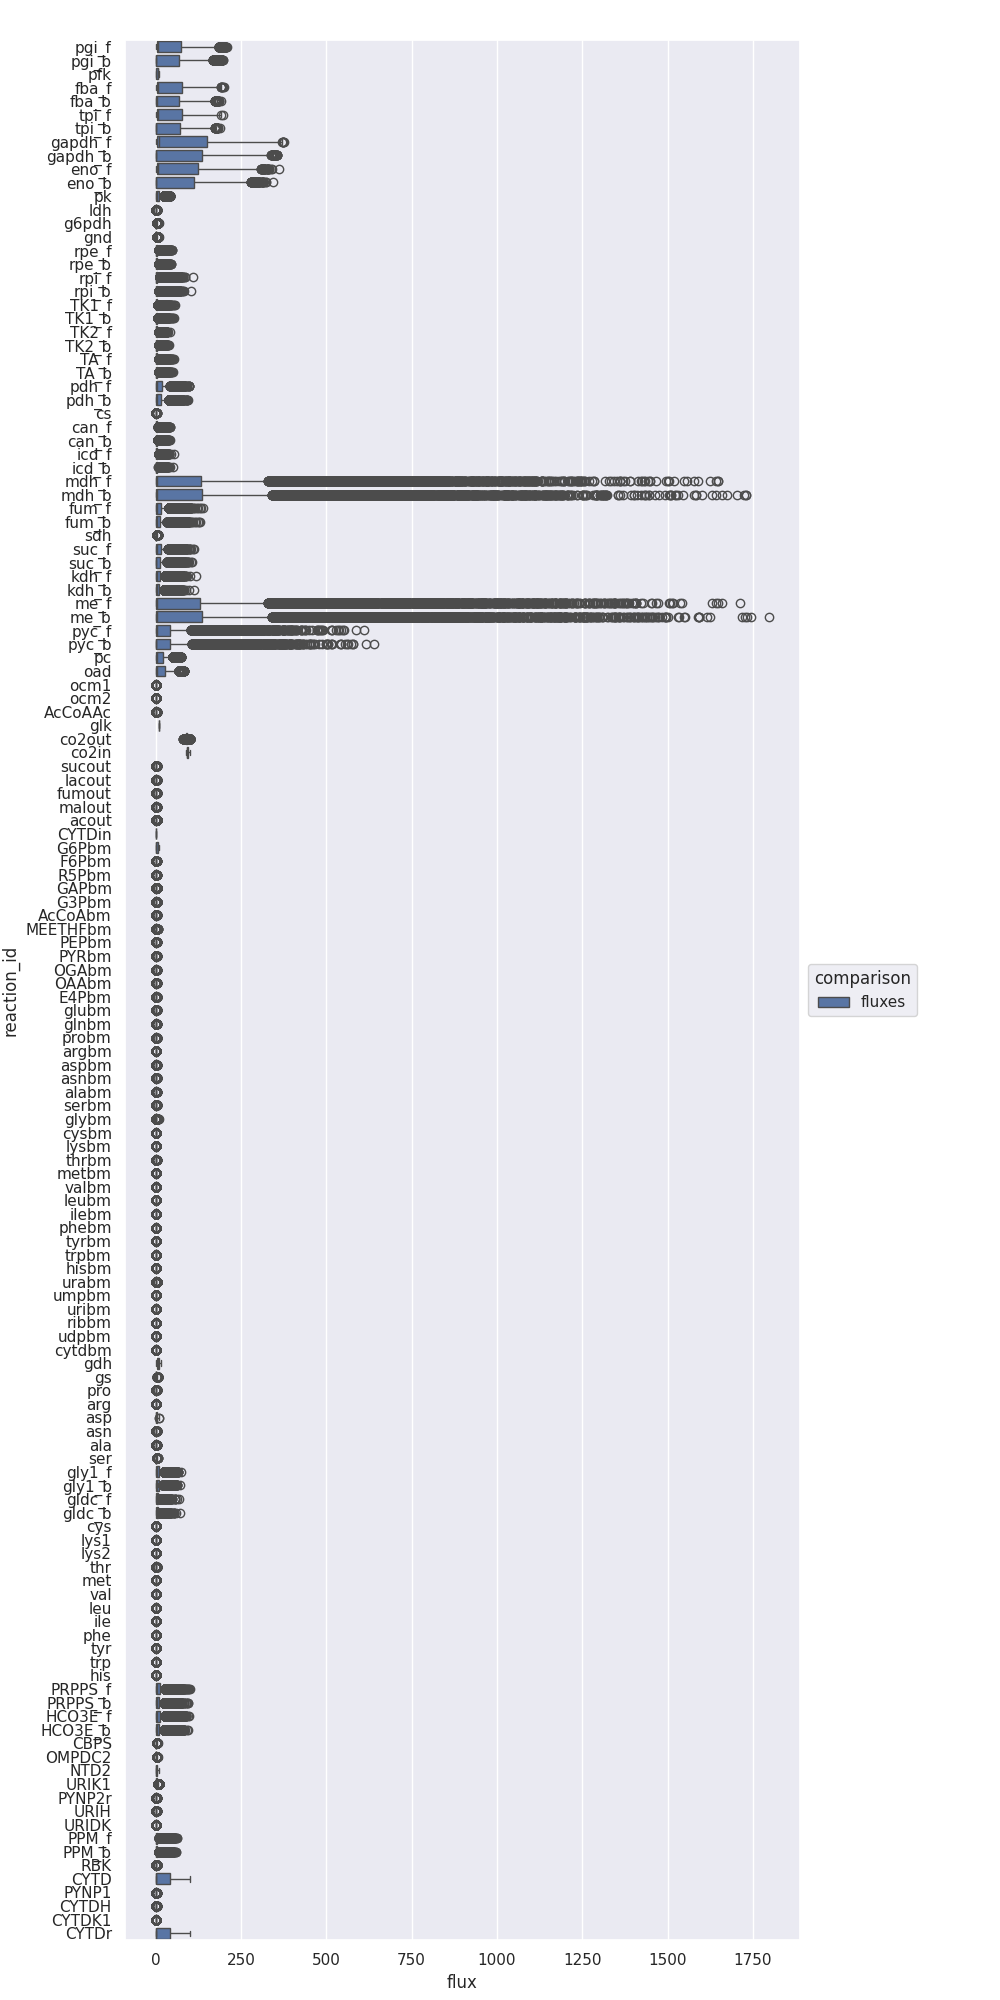

In [8]:
fig = plot_fluxes(
    sns.boxplot,
    fluxes=df_fluxes,
    figsize=(10, 20)
)
fig.subplots_adjust(top=0.98, bottom=0.03)

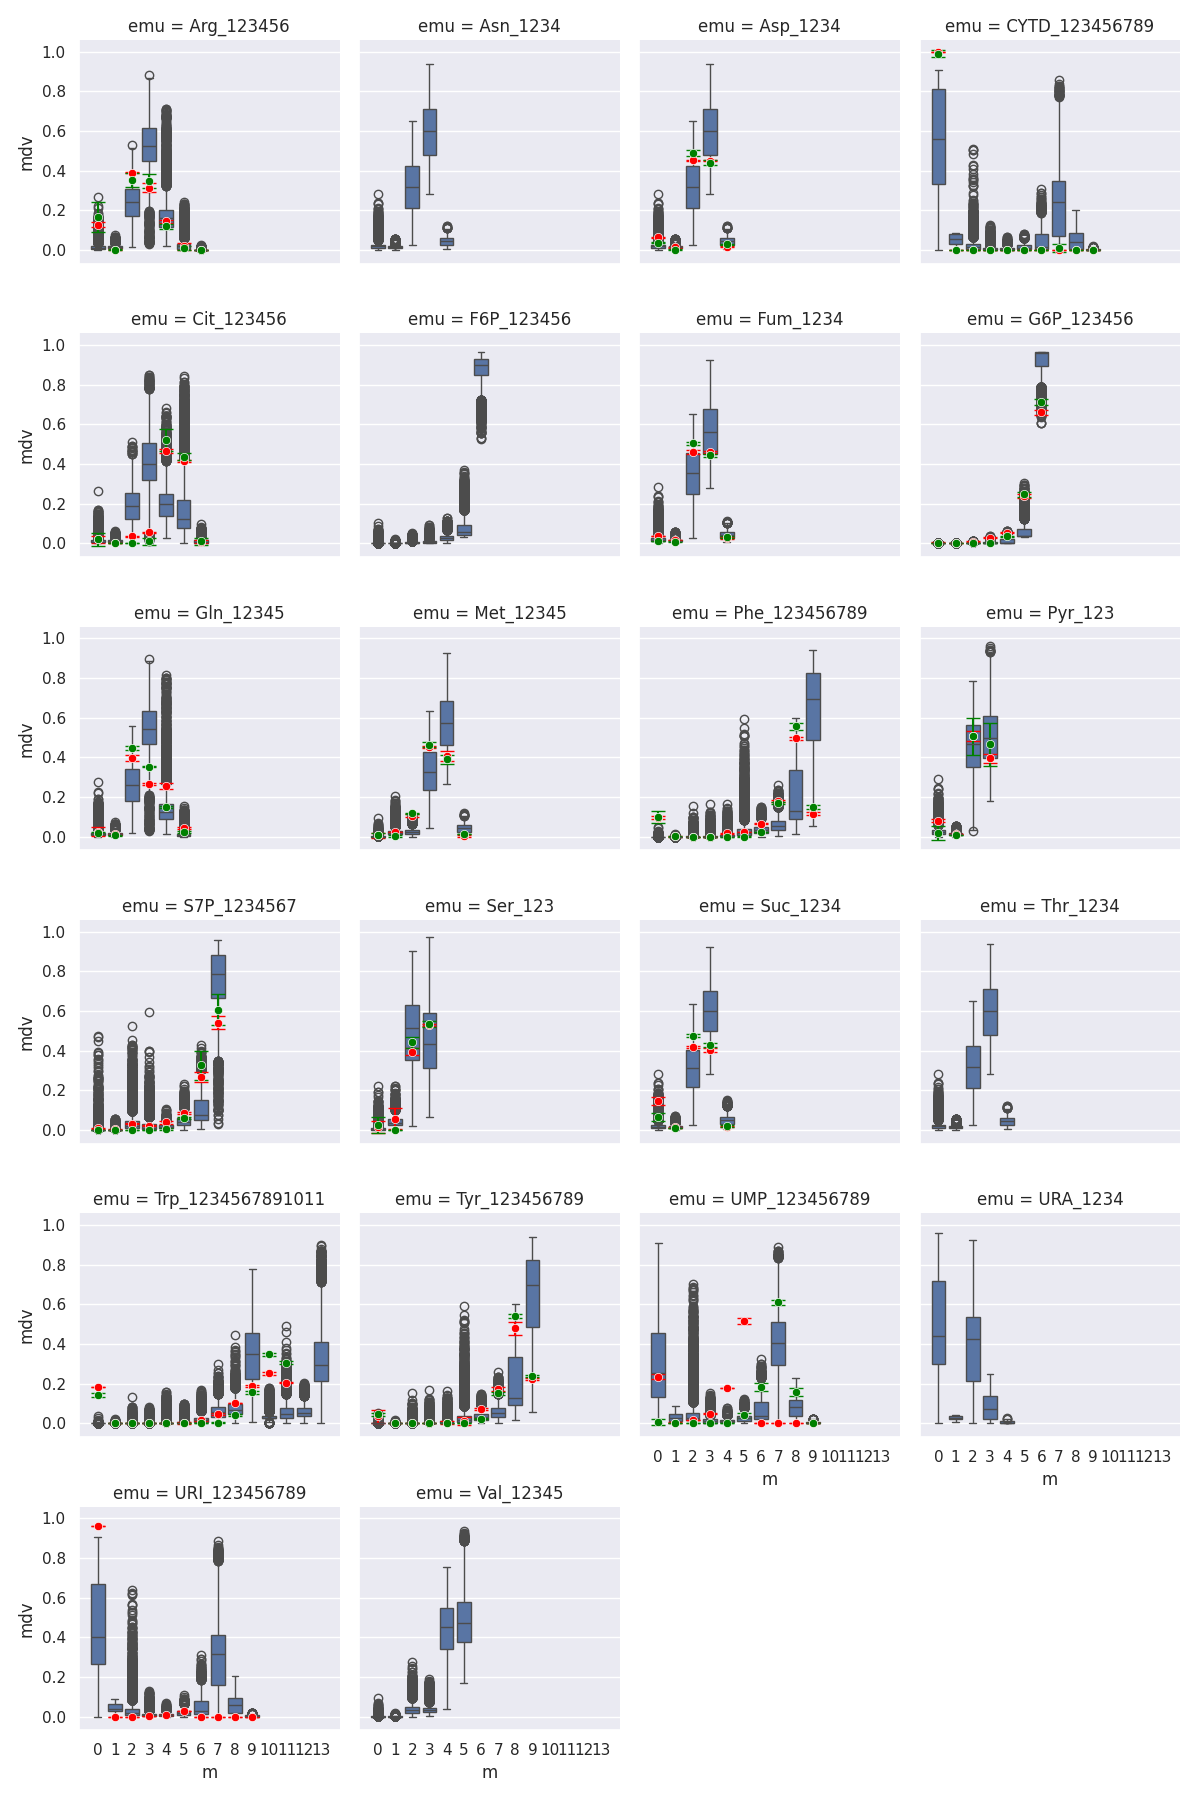

In [8]:
fg = (
    df_mdvs
    .pipe(plot_mdvs_boxplots)
    .pipe(add_exp_points, df_exp.query("medium == 'Cytidine'"))
    .pipe(add_exp_points, df_exp.query("medium == 'Glucose'"), color="green")
)

In [9]:
def add_noise(data, noise_scale=0.01, seed=42):
    rng = np.random.default_rng(seed)
    new_data = (data + rng.uniform(-noise_scale, noise_scale, size=data.shape)).abs()
    return new_data / new_data.sum(axis=0)

In [10]:
df_mdvs_with_noise = (
    df_mdvs
    .reset_index(names="isotopo")
    .pipe(lambda x: x.join(x.isotopo.str.extract("(?P<mb>.*)_.*_.*")))
    .set_index("isotopo")
    .groupby("mb")
    .transform(add_noise)
)

In [11]:
df_exp_w_noise = pd.concat([
    g.assign(mdv=add_noise(g.mdv))
    for idx, g in
    df_exp
    .groupby(["strain", "medium", "emu"], as_index=False)
], ignore_index=True)

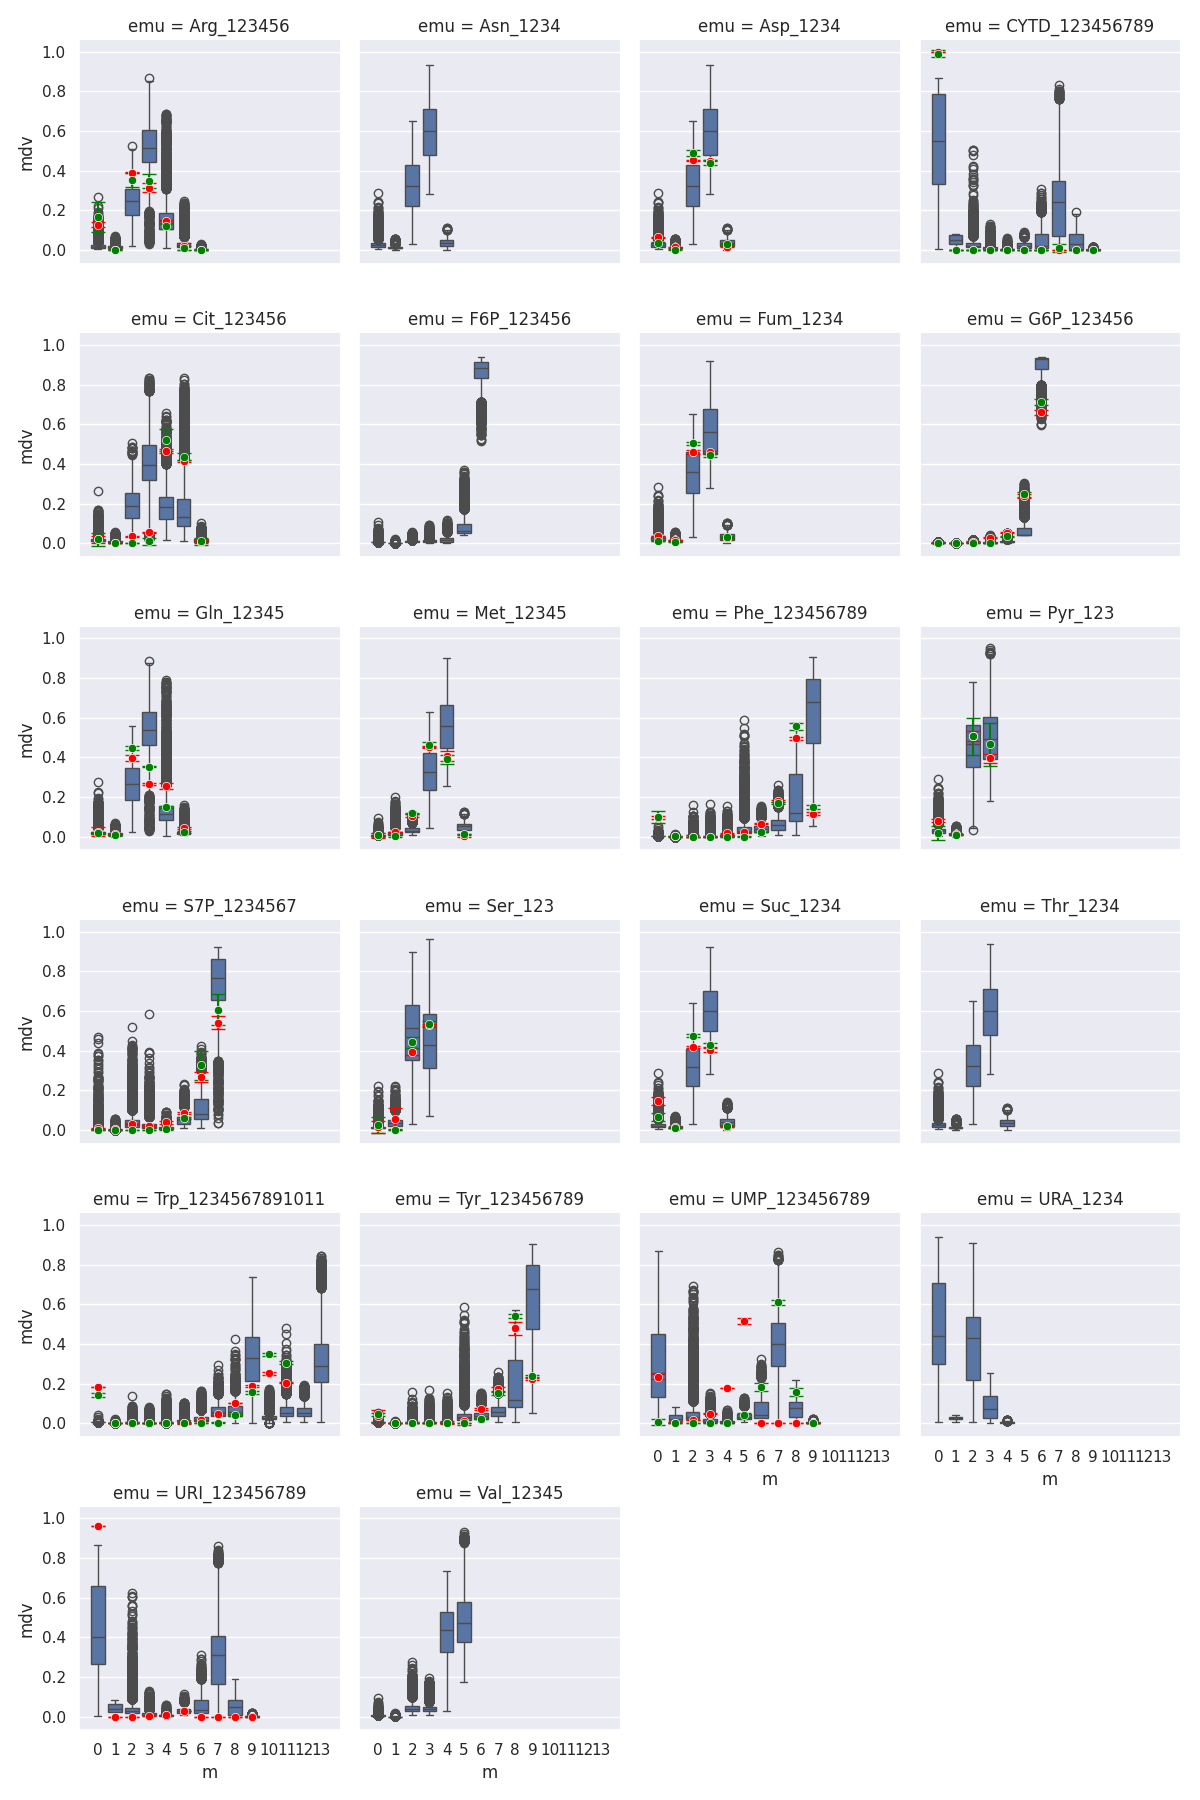

In [12]:
fg = (
    df_mdvs_with_noise
    .pipe(plot_mdvs_boxplots)
    .pipe(add_exp_points, df_exp.query("medium == 'Cytidine'"))
    .pipe(add_exp_points, df_exp.query("medium == 'Glucose'"), color="green")
)

## Additional plots

In [13]:
df_tmp = pd.DataFrame(dict(
    CYTD_123456789_0=
        # pd.concat([df_mdvs1, df_mdvs2], axis=1, ignore_index=True)
        df_mdvs
        .loc["CYTD_123456789_0"].reset_index(drop=True), 
    CYTD_uptake=
        # pd.concat([df_fluxes1, df_fluxes2], axis=1, ignore_index=True)
        df_fluxes
        .pipe(lambda x: x.loc["CYTDin"] / (x.loc["NTD2"] + x.loc["CYTDin"]))
        .reset_index(drop=True),
    CYTDin=
        # pd.concat([df_fluxes1, df_fluxes2], axis=1, ignore_index=True)
        df_fluxes
        .loc["CYTDin"]
))
df_tmp

,CYTD_123456789_0,CYTD_uptake,CYTDin
0,0.279556,0.201550,0.597930
1,0.343716,0.279404,0.689499
2,0.699374,0.679990,0.940169
3,0.504119,0.448218,0.853814
4,0.492748,0.294100,0.971120
...,...,...,...
13695,0.907720,1.000000,0.912147
13696,0.907720,1.000000,0.910020
13697,0.907720,1.000000,0.705822
13698,0.907720,1.000000,0.882217


<Axes: xlabel='CYTDin', ylabel='NTD2'>

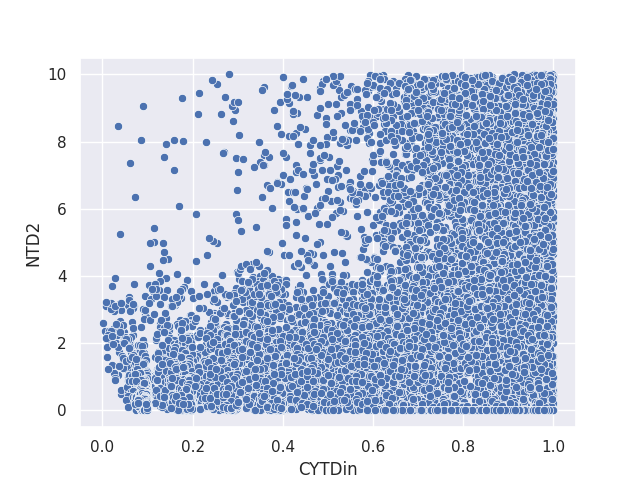

In [14]:
fig, ax = plt.subplots()
sns.scatterplot(df_fluxes.transpose(), x="CYTDin", y="NTD2")

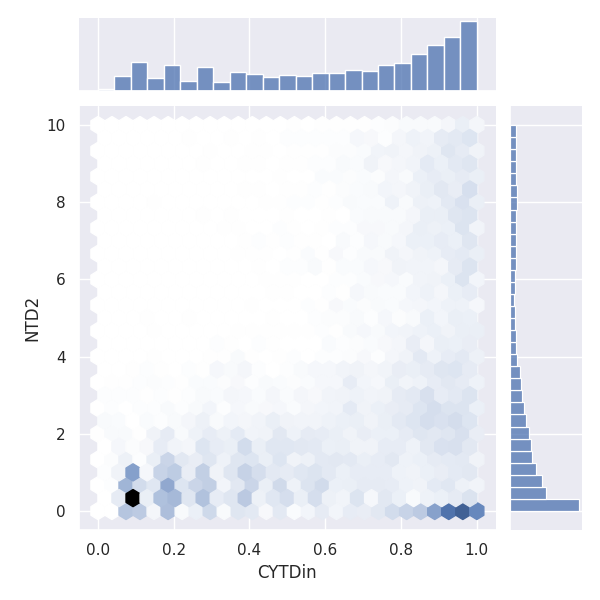

In [15]:
# fig, ax = plt.subplots()
sns.jointplot(df_fluxes.transpose(), x="CYTDin", y="NTD2", kind="hex")

<Axes: xlabel='CYTD_uptake', ylabel='CYTD_123456789_0'>

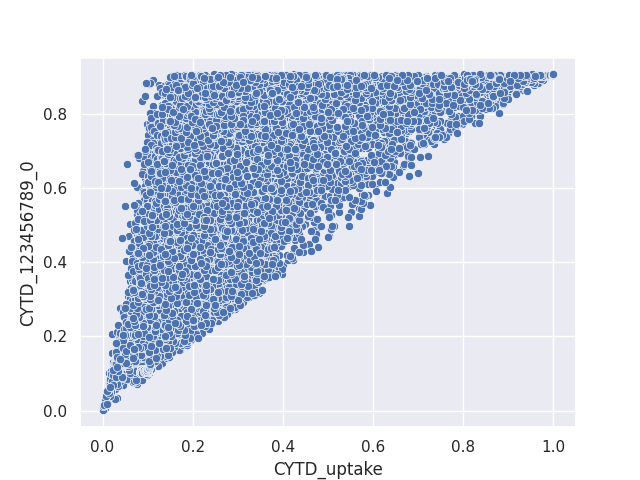

In [16]:
fig, ax = plt.subplots()
sns.scatterplot(df_tmp, x="CYTD_uptake", y="CYTD_123456789_0")

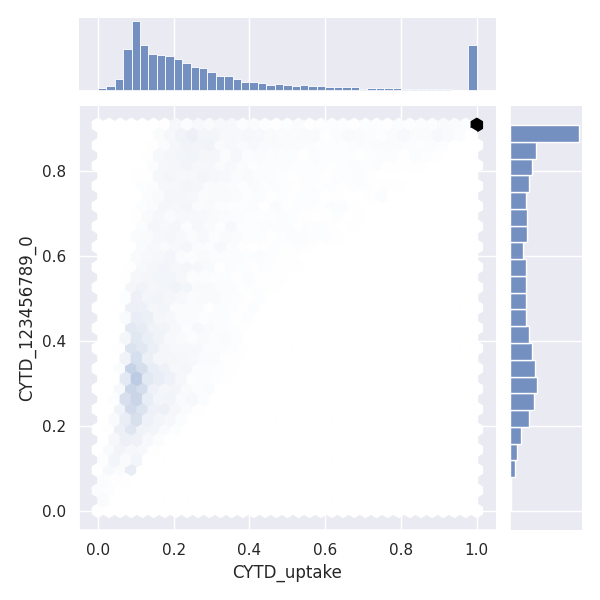

In [17]:
sns.jointplot(df_tmp, x="CYTD_uptake", y="CYTD_123456789_0", kind="hex")

# RF models

## Full

Full RF model on all features in the given nucleoside condition

In [18]:
isotopo_list_full = get_features_list(df_mdvs_with_noise, df_exp, "Cytidine")
df_exp_full = df_exp_w_noise.pipe(get_features_from_exp, "Cytidine", isotopo_list_full)
df_exp_full_glucose = df_exp_w_noise.pipe(get_features_from_exp, "Glucose", isotopo_list_full)
df_mdvs_full = df_mdvs_with_noise.reindex(isotopo_list_full)

In [19]:
res_full, df_feat_imp_full = train_rf_for_all_flux_ratios(df_fluxes, df_mdvs_full, add_flux_ratios_dict)

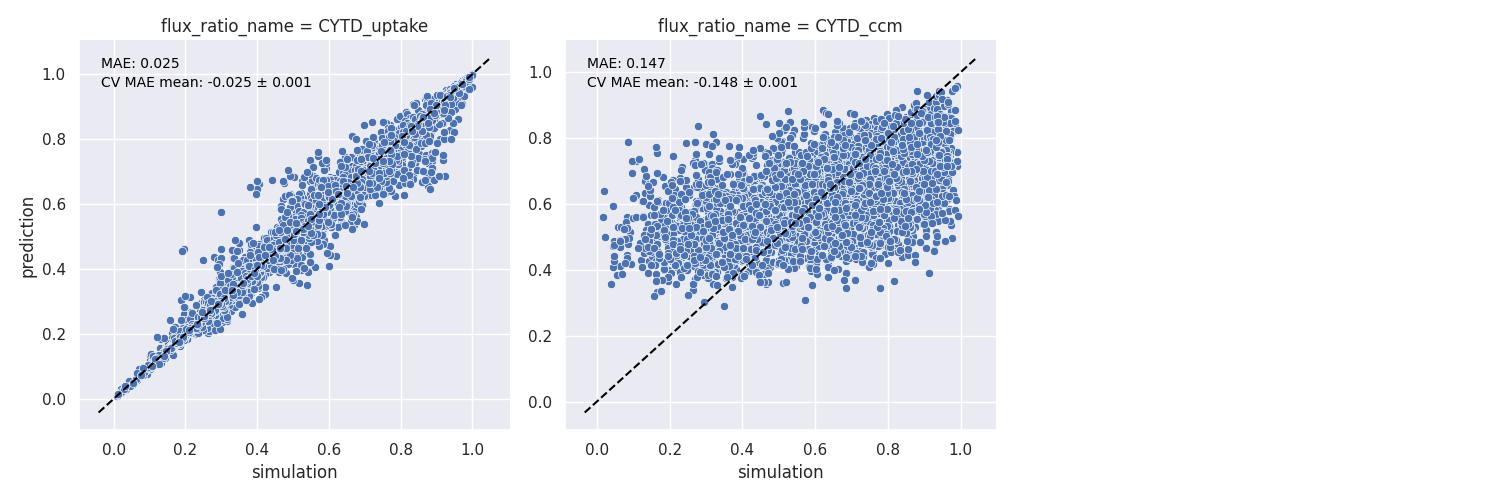

In [20]:
fg = plot_rf_results(res_full, col_wrap=3)

In [21]:
df_pred_full = (
    pd.concat([
        get_rf_pred_results(res_full, df_exp_full, "Cytidine"),
        get_rf_pred_results(res_full, df_exp_full_glucose, "Glucose")
    ], ignore_index=True)
    .assign(comparison="full")
)

df_pred_full

,condition,flux_ratio,pred,pred_q10,pred_q90,mae,cv_mae_mean,cv_mae_sd,nucleoside,flux_ratio_name,comparison
0,Cytidine,CYTD_uptake,0.307873,0.212861,0.355633,0.024979,-0.024585,0.000648,CYTD,uptake,full
1,Cytidine,CYTD_ccm,0.538814,0.252314,0.827454,0.146939,-0.148340,0.000875,CYTD,ccm,full
2,Glucose,CYTD_uptake,NaN,NaN,NaN,0.024979,-0.024585,0.000648,CYTD,uptake,full
3,Glucose,CYTD_ccm,NaN,NaN,NaN,0.146939,-0.148340,0.000875,CYTD,ccm,full


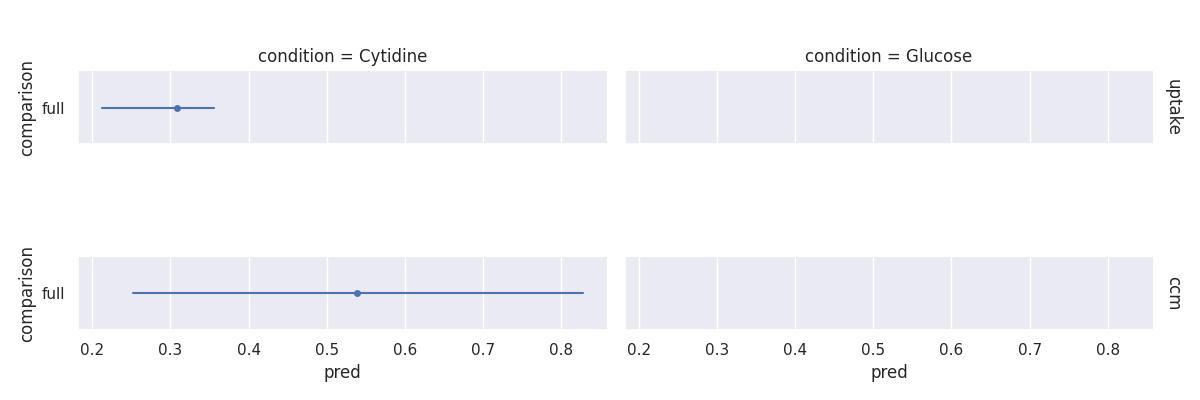

In [22]:
fg = (
    sns.FacetGrid(
        df_pred_full,
        row="flux_ratio_name",
        col="condition",
        aspect=3,
        height=2,
        margin_titles=True
    )
    .map_dataframe(lineplots, y="comparison")
    .set_titles(row_template="{row_name}")
)
fg

In [23]:
df_feat_imp_full

,feature,importance,ratio_name
117,URI_123456789_1,0.703973,CYTD_uptake
13,CYTD_123456789_1,0.108924,CYTD_uptake
107,UMP_123456789_1,0.083543,CYTD_uptake
116,URI_123456789_0,0.034362,CYTD_uptake
12,CYTD_123456789_0,0.025680,CYTD_uptake
...,...,...,...
56,Phe_123456789_3,0.002627,CYTD_ccm
99,Tyr_123456789_3,0.002579,CYTD_ccm
55,Phe_123456789_2,0.002494,CYTD_ccm
98,Tyr_123456789_2,0.002482,CYTD_ccm


## Without nucleoside

RF model on all features in the given nucleoside condition without nucleoside itself

In [24]:
isotopo_list_wo_nuc = get_features_list(df_mdvs_with_noise, df_exp.query("~isotopo.str.startswith('CYTD')"), "Cytidine")
df_exp_wo_nuc = df_exp_w_noise.pipe(get_features_from_exp, "Cytidine", isotopo_list_wo_nuc)
df_exp_wo_nuc_glucose = df_exp_w_noise.pipe(get_features_from_exp, "Glucose", isotopo_list_wo_nuc)
df_mdvs_wo_nuc = df_mdvs_with_noise.reindex(isotopo_list_wo_nuc)

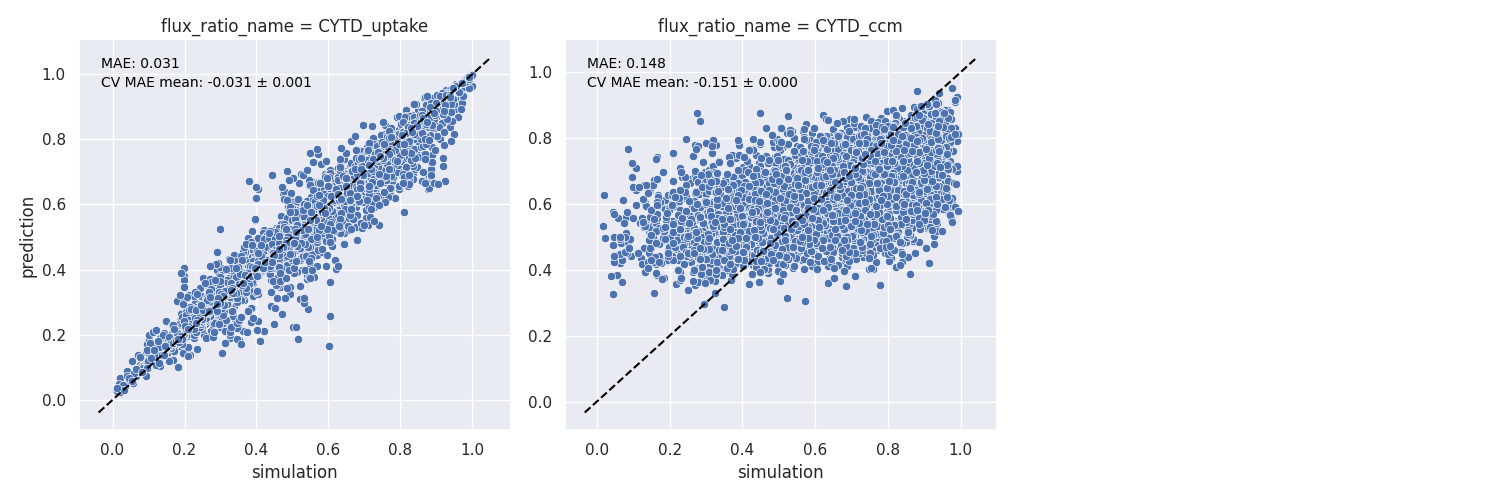

In [25]:
res_wo_nuc, df_feat_imp_wo_nuc = train_rf_for_all_flux_ratios(df_fluxes, df_mdvs_wo_nuc, add_flux_ratios_dict)
fg = plot_rf_results(res_wo_nuc, col_wrap=3)

In [26]:
df_pred_wo_nuc = (
    pd.concat([
        get_rf_pred_results(res_wo_nuc, df_exp_wo_nuc, "Cytidine"),
        get_rf_pred_results(res_wo_nuc, df_exp_wo_nuc_glucose, "Glucose")
    ], ignore_index=True)
    .assign(comparison="wo nuc")
)

df_pred_full

,condition,flux_ratio,pred,pred_q10,pred_q90,mae,cv_mae_mean,cv_mae_sd,nucleoside,flux_ratio_name,comparison
0,Cytidine,CYTD_uptake,0.307873,0.212861,0.355633,0.024979,-0.024585,0.000648,CYTD,uptake,full
1,Cytidine,CYTD_ccm,0.538814,0.252314,0.827454,0.146939,-0.148340,0.000875,CYTD,ccm,full
2,Glucose,CYTD_uptake,NaN,NaN,NaN,0.024979,-0.024585,0.000648,CYTD,uptake,full
3,Glucose,CYTD_ccm,NaN,NaN,NaN,0.146939,-0.148340,0.000875,CYTD,ccm,full


In [27]:
df_exp_wo_nuc.pipe(check_mdv_nan), df_exp_wo_nuc_glucose.pipe(check_mdv_nan)

([], ['URI'])

## Glucose features 

RF model on all features in GLC condition

In [28]:
isotopo_list_glc = get_features_list(df_mdvs_with_noise, df_exp, "Glucose")
df_exp_glc = df_exp_w_noise.pipe(get_features_from_exp, "Cytidine", isotopo_list_glc)
df_exp_glc_glucose = df_exp_w_noise.pipe(get_features_from_exp, "Glucose", isotopo_list_glc)
df_mdvs_glc = df_mdvs_with_noise.reindex(isotopo_list_glc)

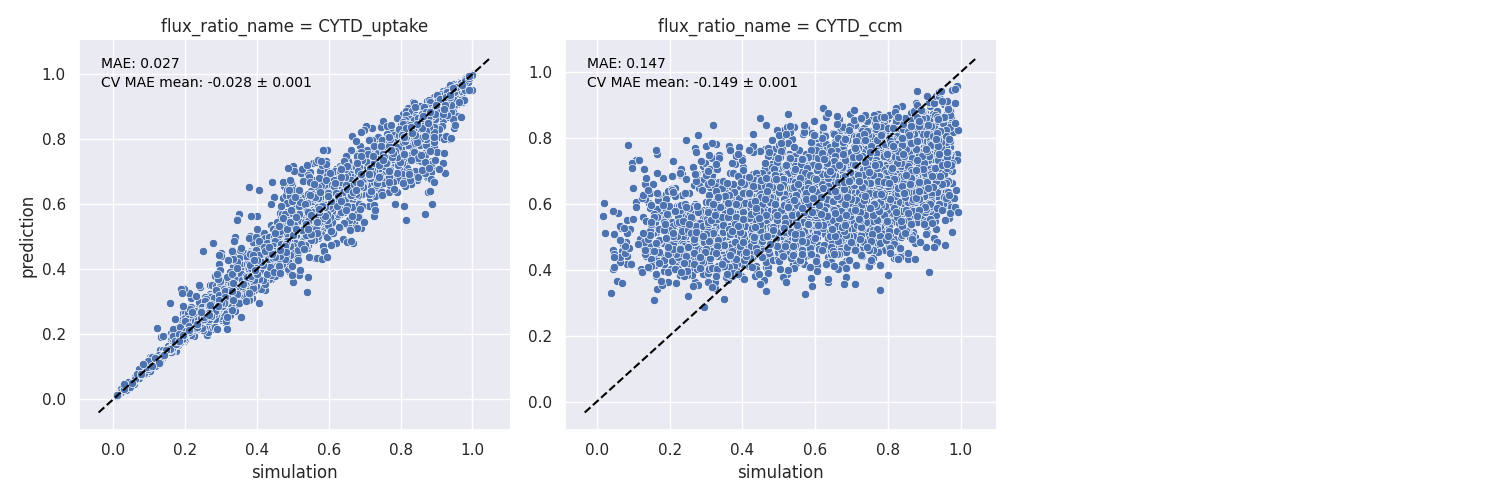

In [29]:
res_glc, df_feat_imp_glc = train_rf_for_all_flux_ratios(df_fluxes, df_mdvs_glc, add_flux_ratios_dict)
fg = plot_rf_results(res_glc, col_wrap=3)

In [30]:
df_pred_glc = (
    pd.concat([
        get_rf_pred_results(res_glc, df_exp_glc, "Cytidine"),
        get_rf_pred_results(res_glc, df_exp_glc_glucose, "Glucose")
    ], ignore_index=True)
    .assign(comparison="glc")
)

df_pred_glc

,condition,flux_ratio,pred,pred_q10,pred_q90,mae,cv_mae_mean,cv_mae_sd,nucleoside,flux_ratio_name,comparison
0,Cytidine,CYTD_uptake,0.646768,0.385848,0.86304,0.027454,-0.027575,0.000650,CYTD,uptake,glc
1,Cytidine,CYTD_ccm,0.54753,0.190955,0.83555,0.147067,-0.148590,0.000695,CYTD,ccm,glc
2,Glucose,CYTD_uptake,0.535194,0.294602,0.751017,0.027454,-0.027575,0.000650,CYTD,uptake,glc
3,Glucose,CYTD_ccm,0.467746,0.134861,0.809405,0.147067,-0.148590,0.000695,CYTD,ccm,glc


In [31]:
df_exp_glc.pipe(check_mdv_nan), df_exp_glc_glucose.pipe(check_mdv_nan)

([], [])

## Both features

RF model on all features detected in both the given nucleoside condition and GLC condition

In [32]:
isotopo_list_both = list(set(isotopo_list_wo_nuc).intersection(isotopo_list_glc))
df_exp_both = df_exp_w_noise.pipe(get_features_from_exp, "Cytidine", isotopo_list_both)
df_exp_both_glucose = df_exp_w_noise.pipe(get_features_from_exp, "Glucose", isotopo_list_both)
df_mdvs_both = df_mdvs_with_noise.reindex(isotopo_list_both)

In [ ]:
res_both, df_feat_imp_both = train_rf_for_all_flux_ratios(df_fluxes, df_mdvs_both, add_flux_ratios_dict)
fg = plot_rf_results(res_both, col_wrap=3)

In [ ]:
df_pred_both = (
    pd.concat([
        get_rf_pred_results(res_both, df_exp_both, "Cytidine"),
        get_rf_pred_results(res_both, df_exp_both_glucose, "Glucose")
    ], ignore_index=True)
    .assign(comparison="both")
)

df_pred_both

In [ ]:
df_exp_both.pipe(check_mdv_nan), df_exp_both_glucose.pipe(check_mdv_nan)

In [ ]:
df_pred_all = pd.concat([
    df_pred_full, df_pred_wo_nuc, df_pred_glc, df_pred_both
], ignore_index=True)
df_pred_all

In [ ]:
fg = (
    sns.FacetGrid(
        df_pred_all,
        row="flux_ratio_name",
        col="condition",
        aspect=3,
        height=2,
        margin_titles=True
    )
    .map_dataframe(lineplots, y="comparison")
    .set_titles(row_template="{row_name}")
)
fg

In [ ]:
df_feat_imp_wo_nuc.query("ratio_name == 'CYTD_uptake'").head(20)

In [ ]:
df_tmp = (
    df_mdvs_full
    .reset_index(names="isotopo")
    .query("isotopo.str.startswith('CYTD')")
    .set_index("isotopo")
    .transpose()
    .melt(ignore_index=False)
    .join(
        (df_fluxes.loc["CYTDin"] / (df_fluxes.loc["OMPDC2"] + df_fluxes.loc["CYTDin"])).to_frame(name="CYTD_uptake")
    )
)

fg = (
    sns.FacetGrid(
        df_tmp,
        col="isotopo",
        col_wrap=4,
        sharex=False
    )
    .map_dataframe(
        sns.scatterplot,
        x="value",
        y="CYTD_uptake"
    )
    .set_titles(col_template="{col_name}")
)

# Feature removal

In [ ]:
df_mdvs_with_noise_sel = (
    df_mdvs_with_noise[(df_mdvs_with_noise > 0.05).any(axis=1)]
)
df_mdvs_with_noise_sel

## Full

Full RF model on all features in the given nucleoside condition

In [ ]:
isotopo_list_full_sel = get_features_list(df_mdvs_with_noise_sel, df_exp, "Cytidine")
df_exp_full_sel = df_exp_w_noise.pipe(get_features_from_exp, "Cytidine", isotopo_list_full_sel)
df_exp_full_sel_glucose = df_exp_w_noise.pipe(get_features_from_exp, "Glucose", isotopo_list_full_sel)
df_mdvs_full_sel = df_mdvs_with_noise_sel.reindex(isotopo_list_full_sel)

In [ ]:
res_full_sel, df_feat_imp_full_sel = train_rf_for_all_flux_ratios(df_fluxes, df_mdvs_full_sel, add_flux_ratios_dict)

In [ ]:
fg = plot_rf_results(res_full_sel, col_wrap=3)

In [ ]:
df_pred_full_sel = (
    pd.concat([
        get_rf_pred_results(res_full_sel, df_exp_full_sel, "Cytidine"),
        get_rf_pred_results(res_full_sel, df_exp_full_sel_glucose, "Glucose")
    ], ignore_index=True)
    .assign(comparison="full_sel")
)

df_pred_full_sel

In [ ]:
def check_mdv_nan(data):
    return (
        data
        .query("mdv.isna()")
        .index.str.extract("(.*)_.*_.*")
        .drop_duplicates()
        .iloc[:, 0]
        .tolist()
    )

In [ ]:
df_exp_full_sel.pipe(check_mdv_nan), df_exp_full_sel_glucose.pipe(check_mdv_nan)

## Without nucleoside

RF model on all features in the given nucleoside condition without nucleoside itself

In [ ]:
isotopo_list_wo_nuc_sel = get_features_list(df_mdvs_with_noise_sel, df_exp.query("~isotopo.str.startswith('CYTD')"), "Cytidine")
df_exp_wo_nuc_sel = df_exp_w_noise.pipe(get_features_from_exp, "Cytidine", isotopo_list_wo_nuc_sel)
df_exp_wo_nuc_sel_glucose = df_exp_w_noise.pipe(get_features_from_exp, "Glucose", isotopo_list_wo_nuc_sel)
df_mdvs_wo_nuc_sel = df_mdvs_with_noise_sel.reindex(isotopo_list_wo_nuc_sel)

In [ ]:
res_wo_nuc_sel, df_feat_imp_wo_nuc_sel = train_rf_for_all_flux_ratios(df_fluxes, df_mdvs_wo_nuc_sel, add_flux_ratios_dict)
fg = plot_rf_results(res_wo_nuc_sel, col_wrap=3)

In [ ]:
df_pred_wo_nuc_sel = (
    pd.concat([
        get_rf_pred_results(res_wo_nuc_sel, df_exp_wo_nuc_sel, "Cytidine"),
        get_rf_pred_results(res_wo_nuc_sel, df_exp_wo_nuc_sel_glucose, "Glucose")
    ], ignore_index=True)
    .assign(comparison="wo nuc sel")
)

df_pred_full_sel

In [ ]:
df_exp_wo_nuc_sel.pipe(check_mdv_nan), df_exp_wo_nuc_sel_glucose.pipe(check_mdv_nan)

## Glucose features 

RF model on all features in GLC condition

In [ ]:
isotopo_list_glc_sel = get_features_list(df_mdvs_with_noise_sel, df_exp, "Glucose")
df_exp_glc_sel = df_exp_w_noise.pipe(get_features_from_exp, "Cytidine", isotopo_list_glc_sel)
df_exp_glc_sel_glucose = df_exp_w_noise.pipe(get_features_from_exp, "Glucose", isotopo_list_glc_sel)
df_mdvs_glc_sel = df_mdvs_with_noise_sel.reindex(isotopo_list_glc_sel)

In [ ]:
res_glc_sel, df_feat_imp_glc_sel = train_rf_for_all_flux_ratios(df_fluxes, df_mdvs_glc_sel, add_flux_ratios_dict)
fg = plot_rf_results(res_glc_sel, col_wrap=3)

In [ ]:
df_pred_glc_sel = (
    pd.concat([
        get_rf_pred_results(res_glc_sel, df_exp_glc_sel, "Cytidine"),
        get_rf_pred_results(res_glc_sel, df_exp_glc_sel_glucose, "Glucose")
    ], ignore_index=True)
    .assign(comparison="glc_sel")
)

df_pred_glc_sel

In [ ]:
df_exp_glc_sel.pipe(check_mdv_nan), df_exp_glc_sel_glucose.pipe(check_mdv_nan)

## Both features

RF model on all features detected in both the given nucleoside condition and GLC condition

In [ ]:
isotopo_list_both_sel = list(set(isotopo_list_wo_nuc_sel).intersection(isotopo_list_glc_sel))
df_exp_both_sel = df_exp_w_noise.pipe(get_features_from_exp, "Cytidine", isotopo_list_both_sel)
df_exp_both_sel_glucose = df_exp_w_noise.pipe(get_features_from_exp, "Glucose", isotopo_list_both_sel)
df_mdvs_both_sel = df_mdvs_with_noise_sel.reindex(isotopo_list_both_sel)

In [ ]:
res_both_sel, df_feat_imp_both_sel = train_rf_for_all_flux_ratios(df_fluxes, df_mdvs_both_sel, add_flux_ratios_dict)
fg = plot_rf_results(res_both_sel, col_wrap=3)

In [ ]:
df_pred_both_sel = (
    pd.concat([
        get_rf_pred_results(res_both_sel, df_exp_both_sel, "Cytidine"),
        get_rf_pred_results(res_both_sel, df_exp_both_sel_glucose, "Glucose")
    ], ignore_index=True)
    .assign(comparison="both_sel")
)

df_pred_both_sel

In [ ]:
df_exp_both_sel.pipe(check_mdv_nan), df_exp_both_sel_glucose.pipe(check_mdv_nan)

In [ ]:
df_pred_all_sel = pd.concat([
    df_pred_full_sel, df_pred_wo_nuc_sel, df_pred_glc_sel, df_pred_both_sel
], ignore_index=True)
df_pred_all_sel

In [ ]:
df_pred = pd.concat([
    df_pred_all.assign(feature_subset=False), 
    df_pred_all_sel.assign(feature_subset=True)
], ignore_index=True)

df_pred.to_csv("../Output/CofeedBuni/cytd_predictions.csv", index=False)

In [ ]:
fg = (
    sns.FacetGrid(
        df_pred_all,
        row="flux_ratio_name",
        col="condition",
        aspect=3,
        height=2,
        margin_titles=True
    )
    .map_dataframe(lineplots, y="comparison")
    .set_titles(row_template="{row_name}")
)
fg

In [ ]:
df_feat_imp_full_sel.query("ratio_name == 'CYTD_uptake'").head(20)

## Additional plots

In [ ]:
df_tmp = (
    df_mdvs_full_sel
    .transpose()
    .melt(ignore_index=False)
    .join(
        (df_fluxes.loc["CYTDin"] / (df_fluxes.loc["OMPDC2"] + df_fluxes.loc["CYTDin"])).to_frame(name="CYTD_uptake")
    )
)

fg = (
    sns.FacetGrid(
        df_tmp.query("isotopo.str.startswith('CYTD')"),
        col="isotopo",
        col_wrap=4,
        sharex=False
    )
    .map_dataframe(
        sns.scatterplot,
        x="value",
        y="CYTD_uptake"
    )
    .set_titles(col_template="{col_name}")
)

In [ ]:
df_mdv_comp = (
    pd.merge(
        df_mdvs
            .melt(ignore_index=False, var_name="sim_num", value_name="mdv_wo_noise")
            .reset_index(names="isotopo"),
        df_mdvs_with_noise
            .melt(ignore_index=False, var_name="sim_num", value_name="mdv_w_noise")
            .reset_index(names="isotopo"),
        on=["isotopo", "sim_num"],
        how="inner"
    )
    .assign(mb=lambda x: x.isotopo.str.extract("(.*)_.*_.*"))
)


In [ ]:
fig, ax = plt.subplots()
sns.scatterplot(df_mdv_comp, x="mdv_wo_noise", y="mdv_w_noise")

In [ ]:
fg = (
    sns.FacetGrid(
        df_mdv_comp.query("mb == 'CYTD'"),
        col="isotopo",
        col_wrap=4,
        sharex=False,
        sharey=False
    )
    .map_dataframe(
        sns.scatterplot,
        x="mdv_wo_noise",
        y="mdv_w_noise"
    )
    .set_titles(col_template="{col_name}")
)

## SHAP

import shap

shap_train, shap_test = train_test_split(
    df_mdvs_full_sel.transpose(),
    test_size=0.3,
    random_state=42,
)

explainer = shap.TreeExplainer(res_full_sel['CYTD_uptake'][0])
rf_prob_shap_vals = explainer(shap_test)

fig, ax = plt.subplots()
shap.plots.beeswarm(rf_prob_shap_vals[:], max_display=20)
fig.subplots_adjust(left=0.4)